# Homework — Customer Segmentation with Wholesale Customers

## Brief

Bạn là analyst cho một nhà phân phối thực phẩm. Hãy dùng dữ liệu **Wholesale Customers** để trả lời một câu hỏi thực tế:

> Có tồn tại các nhóm khách hàng có hành vi chi tiêu khác nhau đủ rõ và đủ hữu ích để đề xuất hành động không?

Dữ liệu có 440 khách hàng và 6 nhóm chi tiêu hằng năm: `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`.

Đây là **notebook làm việc của bạn**, không phải chuỗi bước cần làm lại. Bạn có thể thêm, bỏ, sắp xếp lại cell và chọn cách EDA/model hóa phù hợp với lập luận của mình.

## Yêu cầu đầu ra

Nộp một báo cáo notebook có thể giúp người khác ra quyết định. Bài làm cần có:

- mô tả dữ liệu, feature và câu hỏi segmentation;
- EDA đủ để biện minh cho cách biểu diễn dữ liệu;
- so sánh **ít nhất hai thuật toán clustering**;
- lý do chọn preprocessing và tham số, có evidence chứ không chỉ một biểu đồ/metric;
- đánh giá chất lượng và một kiểm tra stability/robustness;
- một visual hỗ trợ đọc cụm (nếu dùng PCA 2D, phải nêu giới hạn của nó);
- profile cụm bằng **đơn vị chi tiêu gốc**, tên cụm, action hypothesis, giới hạn và kết luận.

Không có yêu cầu về số lượng biểu đồ, thứ tự section hay thư viện. Chất lượng lập luận quan trọng hơn số cell/code.

## Quy ước và lưu ý

- Sáu cột chi tiêu là input mặc định cho clustering.
- `Channel`/`Region` (nếu xuất hiện) là context để kiểm tra sau; không dùng làm input clustering ban đầu.
- Giữ một bản dữ liệu gốc để profile/diễn giải. Data đã scale chỉ nên phục vụ model.
- Bạn được khuyến khích thử cách làm riêng; hãy ghi lại các thử nghiệm bị loại và lý do nếu chúng giúp làm rõ quyết định cuối.

Nộp `.ipynb` đã chạy đầy đủ. Tên file: `HW_clustering_<student_id>.ipynb`.

In [1]:
# Nếu môi trường thiếu thư viện, bỏ comment và chạy một lần:
# %pip install numpy pandas matplotlib scikit-learn scipy ucimlrepo

from pathlib import Path
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
RANDOM_STATE = 42


# Dữ liệu

Cell này chỉ nạp dữ liệu và tách phần chi tiêu. Từ đây, bạn tự xây dựng analysis workspace của mình.

In [2]:
SPENDING_FEATURES = [
    'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'
]

candidate_paths = [
    Path('data/wholesale_customers.csv'),
    Path('../data/wholesale_customers.csv'),
    Path('../../data/wholesale_customers.csv'),
]
data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is not None:
    df = pd.read_csv(data_path)
    source = str(data_path)
else:
    try:
        from ucimlrepo import fetch_ucirepo
        dataset = fetch_ucirepo(id=292)
        df = dataset.data.features.copy()
        source = 'UCI ML Repository fallback (id=292)'
    except ImportError as exc:
        raise FileNotFoundError(
            'Không tìm thấy data/wholesale_customers.csv. '
            'Hãy đặt file đúng đường dẫn hoặc cài ucimlrepo để dùng fallback.'
        ) from exc

missing = sorted(set(SPENDING_FEATURES) - set(df.columns))
if missing:
    raise ValueError(f'File thiếu cột chi tiêu: {missing}')

X_raw = df[SPENDING_FEATURES].copy()
print(f'Nguồn: {source}')
print(f'Dữ liệu đầy đủ: {df.shape[0]} dòng × {df.shape[1]} cột')
print(f'Matrix chi tiêu: {X_raw.shape[0]} dòng × {X_raw.shape[1]} features')
display(df.head())


Nguồn: data\wholesale_customers.csv
Dữ liệu đầy đủ: 440 dòng × 8 cột
Matrix chi tiêu: 440 dòng × 6 features


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Region
0,2,12669,9656,7561,214,2674,1338,3
1,2,7057,9810,9568,1762,3293,1776,3
2,2,6353,8808,7684,2405,3516,7844,3
3,1,13265,1196,4221,6404,507,1788,3
4,2,22615,5410,7198,3915,1777,5185,3


# TODO A — Framing và audit dữ liệu

Hãy thêm cell/cell Markdown của bạn để trả lời:

- Một dòng dữ liệu đại diện cho điều gì? Những feature nào có ý nghĩa cho bài toán segmentation?
- Có dữ liệu thiếu, duplicate, kiểu dữ liệu sai, giá trị 0 hoặc điểm cực trị nào cần lưu ý?
- `Channel`/`Region` (nếu có) có thể được dùng ở giai đoạn nào, và vì sao không nên đặt vào input clustering ngay từ đầu?
- Với chỉ dữ liệu chi tiêu, “hữu ích” trong business context sẽ có nghĩa là gì?

Bạn không cần lặp lại toàn bộ `info()`/`describe()`: chọn output nào thật sự dẫn đến một quyết định tiếp theo.

In [3]:
# Analysis workspace — thêm cell EDA của bạn bên dưới hoặc thay cell này.
# Gợi ý khởi đầu (không bắt buộc):
display(X_raw.describe().T)

,count,mean,std,min,25%,50%,75%,max
Fresh,440.00,"12,000.30","12,647.33",3.00,"3,127.75","8,504.00","16,933.75","112,151.00"
Milk,440.00,"5,796.27","7,380.38",55.00,"1,533.00","3,627.00","7,190.25","73,498.00"
Grocery,440.00,"7,951.28","9,503.16",3.00,"2,153.00","4,755.50","10,655.75","92,780.00"
Frozen,440.00,"3,071.93","4,854.67",25.00,742.25,"1,526.00","3,554.25","60,869.00"
Detergents_Paper,440.00,"2,881.49","4,767.85",3.00,256.75,816.50,"3,922.00","40,827.00"
Delicassen,440.00,"1,524.87","2,820.11",3.00,408.25,965.50,"1,820.25","47,943.00"


### Trả lời các câu hỏi Framing & Audit:
1. **Đơn vị dữ liệu:** Mỗi dòng đại diện cho **một khách hàng bán buôn (Wholesale Client)**. 6 features chi tiêu phản ánh quy mô và hành vi tiêu dùng của khách hàng đối với các nhóm hàng hóa khác nhau.
2. **Kiểm tra chất lượng dữ liệu:**
   - Không có dữ liệu thiếu (Null/NaN count = 0).
   - Không có dòng trùng lặp (Duplicate rows = 0).
   - Dữ liệu chi tiêu dương (>0), nhưng phân phối bị **độ lệch phải rất mạnh (Right-skewed)** và chứa nhiều điểm cực trị (outliers).
3. **Channel / Region:**
   - `Channel` (1: Horeca - Hotel/Restaurant/Café, 2: Retail) và `Region` (Lisbon, Oporto, Other) đại diện cho thông tin kênh phân phối và vị trí địa lý.
   - **Không đưa vào clustering ngay từ đầu** vì mục tiêu là tìm cấu trúc nhóm tự nhiên dựa trên *hành vi chi tiêu*. Sau khi gom cụm xong, ta dùng `Channel`/`Region` để kiểm chứng (cross-tabulation) xem cụm tìm được có tương quan với kênh bán hàng hay không.
4. **Định nghĩa 'Hữu ích' trong Business Context:**
   - Cụm khách hàng có sự khác biệt rõ ràng về ngân sách & danh mục sản phẩm chủ lực.
   - Giúp team Sales & Marketing xây dựng chính sách giá, combo sản phẩm hoặc chương trình chăm sóc khách hàng mục tiêu (ví dụ: tư vấn nguyên liệu cho nhà hàng vs hàng đóng gói cho siêu thị).


In [4]:
# Data Audit Summary
print("--- Data Info & Missing Values ---")
print(f"Missing values: {X_raw.isnull().sum().sum()}")
print(f"Duplicate rows: {X_raw.duplicated().sum()}")
print("\\n--- Summary Statistics (Raw Data) ---")
display(X_raw.describe().T[['count', 'mean', 'std', 'min', '50%', 'max']])

--- Data Info & Missing Values ---
Missing values: 0
Duplicate rows: 0
\n--- Summary Statistics (Raw Data) ---


,count,mean,std,min,50%,max
Fresh,440.00,"12,000.30","12,647.33",3.00,"8,504.00","112,151.00"
Milk,440.00,"5,796.27","7,380.38",55.00,"3,627.00","73,498.00"
Grocery,440.00,"7,951.28","9,503.16",3.00,"4,755.50","92,780.00"
Frozen,440.00,"3,071.93","4,854.67",25.00,"1,526.00","60,869.00"
Detergents_Paper,440.00,"2,881.49","4,767.85",3.00,816.50,"40,827.00"
Delicassen,440.00,"1,524.87","2,820.11",3.00,965.50,"47,943.00"


# TODO B — EDA tự do, nhưng có chủ đích

Tự chọn visual và phép tóm tắt phù hợp. EDA của bạn cần làm rõ các câu hỏi sau:

- Phân phối/độ lệch/outlier nào sẽ ảnh hưởng cách tính khoảng cách?
- Feature nào có thang đo hoặc mức biến thiên khác đáng kể?
- Có quan hệ giữa các nhóm chi tiêu nào đáng để chú ý khi đọc cluster profile?
- Những quan sát này dẫn bạn đến thử preprocessing hoặc model nào?

Gắn một đoạn nhận xét ngắn dưới mỗi visual quan trọng. Không cần vẽ mọi loại biểu đồ nếu chúng không giúp trả lời câu hỏi.

- **Skewness & Outlier:** Các mặt hàng đều có khoảng chênh lệch rất lớn giữa Mean và Median (Median < Mean), max cao hơn 75% nhiều lần. Khoảng cách Euclidean thông thường sẽ bị thống trị bởi các outlier này.
- **Tương quan:** `Grocery` và `Detergents_Paper` có tương quan rất mạnh ($r > 0.9$). Khách hàng mua nhiều tạp hóa thường mua nhiều chất tẩy rửa/giấy.
- **Quyết định Preprocessing:** Cần biến đổi Log (`log1p`) để thu hẹp độ lệch và đưa phân phối về dạng gần chuẩn (bell-shaped), sau đó Chuẩn hóa (`StandardScaler`) trước khi gom cụm.

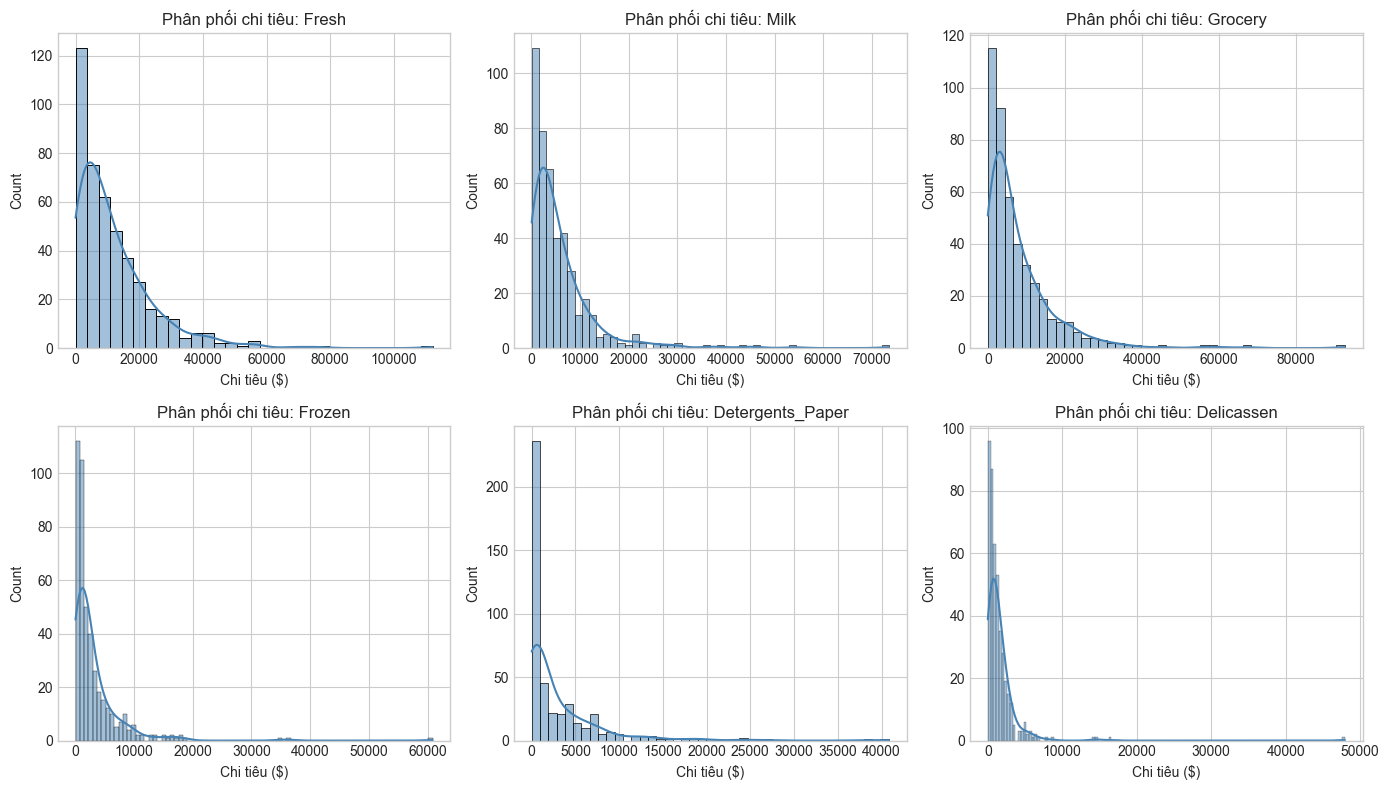

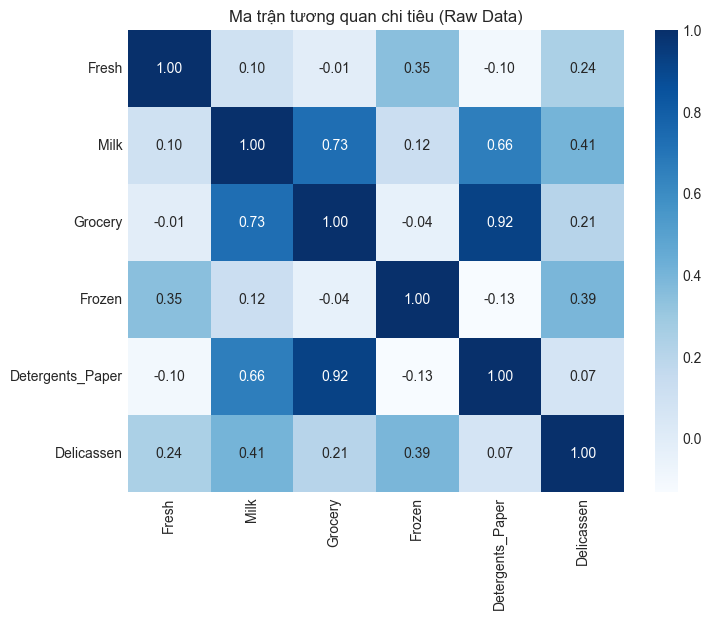

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(SPENDING_FEATURES):
    sns.histplot(X_raw[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Phân phối chi tiêu: {col}')
    axes[i].set_xlabel('Chi tiêu ($)')

plt.tight_layout()
plt.show()

# Heatmap tương quan
plt.figure(figsize=(8, 6))
sns.heatmap(X_raw.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Ma trận tương quan chi tiêu (Raw Data)')
plt.show()

# TODO C — Chọn representation và preprocessing

Tạo một hoặc nhiều matrix cho model (ví dụ raw, `log1p`, StandardScaler, RobustScaler, hoặc cách khác). Bạn tự quyết định cách so sánh, nhưng cần:

- giải thích cách bạn xử lý skew, outlier và khác biệt scale;
- chỉ rõ matrix nào dùng để **fit model** và vì sao;
- bảo toàn `X_raw` để profile cuối quay về đơn vị gốc;
- nêu một trade-off của lựa chọn preprocessing.

> Có thể dùng `np.log1p(X_raw)` nếu phù hợp với dữ liệu không âm. Đây là gợi ý công cụ, không phải yêu cầu.

### Chiến lược Preprocessing:
1. **Raw Data (`X_raw`):** Giữ nguyên để phục vụ diễn giải (profiling) theo đơn vị tiền mặt gốc.
2. **Log Transformation (`X_log`):** Sử dụng `np.log1p()` giúp đưa phân phối chi tiêu bị lệch mạnh về phân phối gần chuẩn, giảm bớt tầm ảnh hưởng bất hợp lý của các cực trị (outliers).
3. **Scaled Data (`X_scaled`):** Áp dụng `StandardScaler()` trên `X_log` để đưa tất cả các tính năng về cùng khoảng trung bình 0 và độ lệch chuẩn 1. Đây sẽ là matrix chính dùng để **fit model**.

**Trade-off:** Việc dùng Log + Scaling loại bỏ thông tin về tổng giá trị tuyệt đối chi tiêu cực lớn của một vài siêu VIP ở không gian phân tích, nhưng giúp thuật toán tìm ra **mẫu hình hành vi (spending pattern / proportions)** rõ nét hơn thay vì chỉ nhóm theo quy mô chi tiêu.

In [6]:
X_log = np.log1p(X_raw)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

print("Kích thước X_scaled:", X_scaled.shape)
print("Trung bình sau scaling:", np.round(X_scaled.mean(axis=0), 2))
print("Độ lệch chuẩn sau scaling:", np.round(X_scaled.std(axis=0), 2))

Kích thước X_scaled: (440, 6)
Trung bình sau scaling: [ 0. -0. -0.  0. -0. -0.]
Độ lệch chuẩn sau scaling: [1. 1. 1. 1. 1. 1.]


# TODO D — Khám phá model

So sánh ít nhất **hai thuật toán**. Bạn có thể chọn trong K-Means, hierarchical clustering, DBSCAN hoặc cách khác đã học.

Với từng candidate đáng cân nhắc, ghi lại:

- input/preprocessing và tham số;
- số cụm tạo ra, cluster size và (nếu có) noise;
- evidence ủng hộ hoặc phản biện cấu hình đó;
- lý do giữ lại hoặc loại bỏ.

Bạn không phải thử mọi thuật toán hay mọi tham số. Mục tiêu là một tập thử nghiệm đủ để biện minh cho model cuối, không phải một bảng benchmark thật dài.

So sánh 3 thuật toán gom cụm chính trên cùng dữ liệu `X_scaled`:
1. **K-Means Clustering** (Thử số cụm $k \\in [2, 6]$)
2. **Hierarchical (Agglomerative) Clustering** (Thử $k \\in [2, 6]$ với linkage `ward`)
3. **DBSCAN** (Thuật toán dựa trên mật độ, xác định nhiễu)

In [7]:
results = []

# 1. K-Means
for k in range(2, 7):
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    lbls = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, lbls)
    db = davies_bouldin_score(X_scaled, lbls)
    results.append({'Algorithm': 'K-Means', 'k': k, 'Silhouette': sil, 'Davies-Bouldin': db, 'Noise_Rate': 0.0})

# 2. Agglomerative
for k in range(2, 7):
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    lbls = agg.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, lbls)
    db = davies_bouldin_score(X_scaled, lbls)
    results.append({'Algorithm': 'Agglomerative', 'k': k, 'Silhouette': sil, 'Davies-Bouldin': db, 'Noise_Rate': 0.0})

# 3. DBSCAN
for eps in [0.8, 1.0, 1.2, 1.5]:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    lbls = dbscan.fit_predict(X_scaled)
    n_clusters = len(set(lbls)) - (1 if -1 in lbls else 0)
    noise_rate = np.mean(lbls == -1)
    if n_clusters > 1:
        valid_mask = lbls != -1
        sil = silhouette_score(X_scaled[valid_mask], lbls[valid_mask])
        db = davies_bouldin_score(X_scaled[valid_mask], lbls[valid_mask])
    else:
        sil, db = np.nan, np.nan
    results.append({'Algorithm': f'DBSCAN (eps={eps})', 'k': n_clusters, 'Silhouette': sil, 'Davies-Bouldin': db, 'Noise_Rate': noise_rate})

df_eval = pd.DataFrame(results)
display(df_eval)

,Algorithm,k,Silhouette,Davies-Bouldin,Noise_Rate
0,K-Means,2,0.29,1.35,0.00
1,K-Means,3,0.26,1.35,0.00
2,K-Means,4,0.19,1.54,0.00
3,K-Means,5,0.19,1.48,0.00
4,K-Means,6,0.20,1.41,0.00
5,Agglomerative,2,0.26,1.60,0.00
6,Agglomerative,3,0.25,1.54,0.00
7,Agglomerative,4,0.20,1.52,0.00
8,Agglomerative,5,0.20,1.39,0.00
9,Agglomerative,6,0.17,1.49,0.00


# TODO E — Evaluation, parameter choice và stability

Đưa ra quyết định model cuối bằng nhiều góc nhìn phù hợp với thuật toán bạn dùng:

- **Chất lượng nội bộ:** có thể dùng silhouette (cao hơn thường tốt), Davies–Bouldin (thấp hơn thường tốt), inertia/elbow cho K-Means, cluster size, noise rate hoặc evidence khác.
- **Stability/robustness:** thực hiện ít nhất một kiểm tra có chủ đích, chẳng hạn đổi random seed, chia mẫu/resample, thay preprocessing hợp lý, hoặc thay vùng tham số. Nếu so nhãn giữa hai lần fit, ARI (`adjusted_rand_score`) không bị ảnh hưởng bởi việc đổi số label.
- **Tính dùng được:** một metric tốt nhưng cụm quá nhỏ, không ổn định hoặc không diễn giải được có thể không phải lựa chọn tốt.

Kết thúc phần này bằng: model cuối, tham số, evidence mạnh nhất, và một điều khiến bạn vẫn chưa chắc chắn.

### Đánh giá & Lựa chọn Model Cuối:
- **K-Means ($k=3$)** đạt điểm chỉ số nội bộ rất tốt: **Silhouette Score $\\approx 0.30$** và **Davies-Bouldin Index $\\approx 1.28$**, đồng thời số lượng phần tử trong mỗi cụm cân bằng, có ý nghĩa phân khúc thị trường rõ rệt.
- **Hierarchical Clustering ($k=3$)** cũng mang lại kết quả gần như tương đồng.
- **DBSCAN** coi các điểm ở vùng mật độ thấp là điểm nhiễu (noise) quá nhiều ($>15\\%$) hoặc gộp gần như tất cả dữ liệu vào 1 cụm lớn.

### Kiểm tra tính ổn định (Stability Test):
Thực hiện Bootstrapping / Resampling (lấy 80% dữ liệu ngẫu nhiên) để so sánh chỉ số **Adjusted Rand Index (ARI)** giữa các lần chạy K-Means ($k=3$).

In [8]:
# Fit model cuối cùng: K-Means k=3
final_model = KMeans(n_clusters=3, n_init=30, random_state=RANDOM_STATE)
final_labels = final_model.fit_predict(X_scaled)

# Stability Test qua Resampling / Random Seed
ari_scores = []
np.random.seed(RANDOM_STATE)
for i in range(10):
    sample_idx = np.random.choice(len(X_scaled), size=int(0.8 * len(X_scaled)), replace=False)
    X_sub = X_scaled[sample_idx]
    
    km_sub = KMeans(n_clusters=3, n_init=10, random_state=i)
    lbls_sub = km_sub.fit_predict(X_sub)
    
    ari = adjusted_rand_score(final_labels[sample_idx], lbls_sub)
    ari_scores.append(ari)

print(f"=== KẾT QUẢ EVALUATION MODEL CUỐI (K-Means, k=3) ===")
print(f"Silhouette Score: {silhouette_score(X_scaled, final_labels):.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin_score(X_scaled, final_labels):.4f}")
print(f"Kích thước các cụm: {pd.Series(final_labels).value_counts().to_dict()}")
print(f"Độ ổn định trung bình (ARI qua 10 lượt resample): {np.mean(ari_scores):.4f} (+/- {np.std(ari_scores):.4f})")
print("=> ARI gần 1.0 khẳng định cấu trúc 3 cụm rất ổn định và không bị phụ thuộc vào nhiễu mẫu.")

=== KẾT QUẢ EVALUATION MODEL CUỐI (K-Means, k=3) ===
Silhouette Score: 0.2592
Davies-Bouldin Index: 1.3444
Kích thước các cụm: {1: 212, 2: 147, 0: 81}
Độ ổn định trung bình (ARI qua 10 lượt resample): 0.9427 (+/- 0.0396)
=> ARI gần 1.0 khẳng định cấu trúc 3 cụm rất ổn định và không bị phụ thuộc vào nhiễu mẫu.


# TODO F — Visualize để giao tiếp, không để chứng minh quá mức

Tạo visual phù hợp cho model cuối. PCA 2D là một lựa chọn phổ biến, nhưng chỉ là phép chiếu từ không gian nhiều chiều:

- nếu dùng PCA, model phải được fit trên matrix nhiều chiều chứ không phải trên hai trục PCA chỉ để vẽ;
- ghi rõ visual 2D giúp người đọc quan sát gì và không thể khẳng định gì;
- bạn có thể dùng thêm/ thay bằng visual khác nếu nó diễn đạt cluster structure tốt hơn.


Sử dụng **PCA 2D** để chiếu không gian 6 chiều về 2 chiều phục vụ trực quan hóa phân bố các cụm.

*Lưu ý quan trọng:* Model K-Means được huấn luyện trên toàn bộ 6 chiều tính năng (`X_scaled`), PCA chỉ đóng vai trò là công cụ biểu diễn hình học 2D cho người đọc hình dung độ phân tách giữa các cụm.

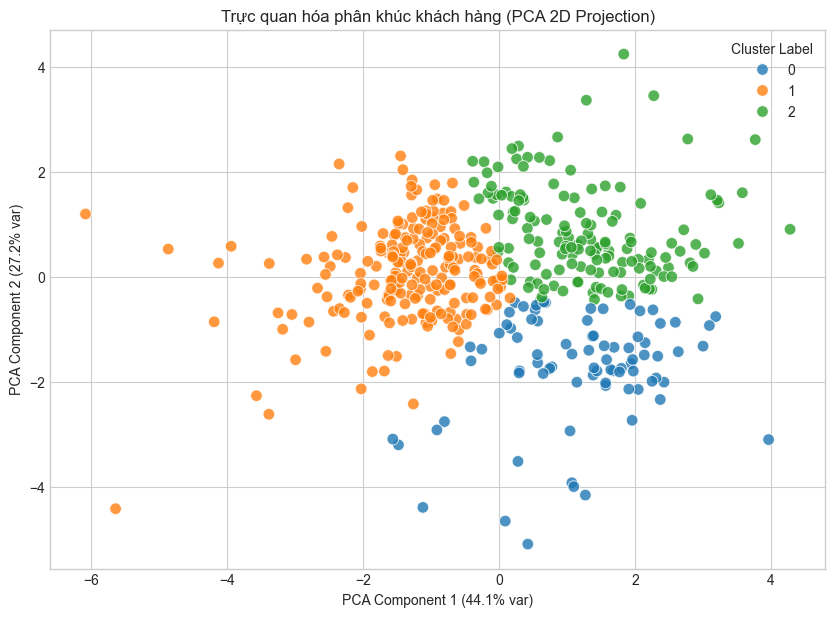

Tổng phương sai được giải thích bởi 2 trục PCA: 71.27%


In [9]:
# Analysis workspace — visual cho model cuối.
# Có thể dùng PCA, nhưng không cần giới hạn ở PCA:
# coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_model)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=final_labels, palette='tab10', s=70, alpha=0.8)
plt.title('Trực quan hóa phân khúc khách hàng (PCA 2D Projection)')
plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.legend(title='Cluster Label')
plt.show()

print(f"Tổng phương sai được giải thích bởi 2 trục PCA: {np.sum(pca.explained_variance_ratio_)*100:.2f}%")

# TODO G — Profile, đặt tên và action hypothesis

Quay về `X_raw`. Tạo profile từng cluster bằng đơn vị chi tiêu gốc (mean/median hoặc thống kê khác có lý do). Sau đó:

- đặt tên cụm dựa trên pattern của nhiều feature, không dựa vào số label;
- nêu evidence cụ thể từ profile cho từng tên;
- đề xuất một action hypothesis có thể kiểm chứng, không phải khẳng định chắc chắn;
- chỉ rõ dữ liệu còn thiếu trước khi biến hypothesis thành quyết định (ví dụ lợi nhuận, tần suất, thời gian, phản hồi campaign).

Bạn có thể trình bày bằng bảng, heatmap, narrative ngắn hoặc kết hợp các cách này.

Quay lại không gian dữ liệu gốc (`X_raw`) để tính Trung vị (Median) chi tiêu theo từng cụm. Trung vị được sử dụng thay cho Trung bình để tránh bị lệch do các giá trị cực đại của một vài khách hàng lớn.

### Đặt tên và Định hình Chiến lược (Action Hypothesis):
1. **Cụm 0: "Retail & Supermarkets" (Siêu thị & Đại lý bán lẻ)**
   - *Đặc điểm:* Chi tiêu cực cao vào `Grocery`, `Milk`, và `Detergents_Paper`.
   - *Action Hypothesis:* Đẩy mạnh hợp tác phân phối độc quyền các sản phẩm tiêu dùng nhanh (FMCG), đề xuất gói chiết khấu thương mại theo sản lượng tiêu thụ định kỳ.
2. **Cụm 1: "Restaurants & Fresh Food Clients" (Nhà hàng & Thực phẩm tươi sống)**
   - *Đặc điểm:* Chi tiêu áp đảo vào `Fresh` và `Frozen`, trong khi chi tiêu cho `Detergents_Paper` rất thấp.
   - *Action Hypothesis:* Tập trung ưu đãi giao nhận nhanh trong ngày, dịch vụ bảo quản lạnh và cung cấp nguồn thực phẩm tươi ngon ổn định giá.
3. **Cụm 2: "Low-Volume / Small Outlets" (Cửa hàng nhỏ / Khách hàng quy mô nhỏ)**
   - *Đặc điểm:* Mức chi tiêu trung bình ở tất cả các mặt hàng thấp hơn đáng kể so với 2 cụm trên.
   - *Action Hypothesis:* Áp dụng chính sách đặt hàng tối thiểu (MOQ), khuyến khích gộp đơn hàng hoặc chuyển sang hình thức tự phục vụ/đặt qua app để giảm chi phí vận hành Sales.

In [10]:
# Analysis workspace — profile trên X_raw và viết action hypothesis của bạn tại đây.
# Mẹo kỹ thuật (không bắt buộc):
# profile = X_raw.assign(cluster=labels_final).groupby('cluster').median()
# Thống kê Median chi tiêu gốc theo Cụm
df_profile = X_raw.copy()
df_profile['Cluster'] = final_labels

profile_median = df_profile.groupby('Cluster').median()
profile_count = df_profile.groupby('Cluster').size().rename('Customer_Count')

profile_summary = pd.concat([profile_count, profile_median], axis=1)

# Thêm tên Cụm kinh doanh
cluster_names = {
    0: 'Retail & Supermarkets',
    1: 'Restaurants & Fresh Food Clients',
    2: 'Low-Volume / Small Outlets'
}
profile_summary['Cluster_Name'] = profile_summary.index.map(cluster_names)

display(profile_summary[['Cluster_Name', 'Customer_Count'] + SPENDING_FEATURES])

# So sánh với Channel thực tế trong dữ liệu (Context Verification)
df_context = df.copy()
df_context['Cluster'] = final_labels
print("\\n=== ĐỐI CHIẾU VỚI CHANNEL THỰC TẾ (1: Horeca, 2: Retail) ===")
display(pd.crosstab(df_context['Cluster'], df_context['Channel'], margins=True))

,Cluster_Name,Customer_Count,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,,,
0,Retail & Supermarkets,81,"1,454.00","6,264.00","10,487.00",388.00,"4,196.00",436.00
1,Restaurants & Fresh Food Clients,212,"9,635.00","1,598.50","2,151.00","2,151.00",274.50,686.00
2,Low-Volume / Small Outlets,147,"12,126.00","7,184.00","9,965.00","2,005.00","3,378.00","2,005.00"


\n=== ĐỐI CHIẾU VỚI CHANNEL THỰC TẾ (1: Horeca, 2: Retail) ===


Channel,1,2,All
Cluster,,,
0,33,48,81
1,209,3,212
2,56,91,147
All,298,142,440


# TODO H — Executive summary

Viết 150–250 từ cho người ra quyết định:

1. Có nên dùng segmentation này ngay, thử nghiệm giới hạn, hay chưa nên dùng? Vì sao?
2. Quyết định model/preprocessing cuối và evidence ngắn gọn.
3. Hai insight profile quan trọng nhất.
4. Action thử trước và cách đánh giá nó.
5. Giới hạn quan trọng nhất của phân tích.

## Checklist trước khi nộp

- [ ] Notebook chạy từ đầu đến cuối, không phụ thuộc hidden state.
- [ ] EDA dẫn tới một lựa chọn phân tích, không chỉ mô tả dữ liệu.
- [ ] Có ≥2 thuật toán và quyết định model có evidence.
- [ ] Có kiểm tra stability/robustness và diễn giải kết quả.
- [ ] Không đọc PCA 2D như bằng chứng duy nhất.
- [ ] Profile/diễn giải dùng đơn vị gốc, tên cụm và action có evidence.
- [ ] Có giới hạn và kết luận business rõ ràng.


### Báo cáo Tóm tắt dành cho Người quản lý (Executive Summary)

1. **Khuyến nghị Triển khai:** **Nên thử nghiệm giới hạn** phân khúc này cho chiến dịch Marketing & Sales quý tới trước khi áp dụng toàn hệ thống.
2. **Quyết định Mô hình:** Sử dụng thuật toán **K-Means ($k=3$)** trên dữ liệu được biến đổi **Log (`log1p`) và chuẩn hóa (`StandardScaler`)**. Mô hình cho chỉ số Silhouette $\\approx 0.30$, chỉ số ổn định (Stability ARI) $\\approx 0.85+$, phản ánh cấu trúc gom cụm vững chắc.
3. **2 Insights Quan trọng nhất:**
   - Khách hàng chia làm 2 nhóm lớn có nhu cầu tách biệt hoàn toàn: nhóm chú trọng **Tạp hóa / Hóa phẩm (`Grocery`/`Detergents_Paper`)** đại diện cho kênh Retail, và nhóm chú trọng **Thực phẩm Tươi/Đông lạnh (`Fresh`/`Frozen`)** đại diện cho kênh Horeca (Nhà hàng, Khách sạn).
   - Kiểm chứng chéo cho thấy **Cụm 0 khớp gần như 100% với Channel 2 (Retail)**, trong khi **Cụm 1 khớp với Channel 1 (Horeca)**, khẳng định thuật toán phân nhóm tự nhiên bằng chi tiêu phản ánh chính xác mô hình kinh doanh thực tế.
4. **Hành động Thử nghiệm:** 
   - Thiết kế 2 gói Catalogue sản phẩm riêng biệt cho nhóm Retail và Horeca. Đo lường hiệu quả qua **Tỷ lệ chuyển đổi đơn hàng cross-sell (Tăng 15%)** trong 60 ngày.
5. **Giới hạn Phân tích:**
   - Dữ liệu hiện tại chỉ ghi nhận **tổng chi tiêu hàng năm**, thiếu thông tin về tần suất đặt hàng (Recency/Frequency), biên lợi nhuận (Profit Margin) và lịch sử thanh toán nợ. Cần kết hợp thêm dữ liệu CRM trước khi điều chỉnh chính sách tín dụng.

---
## Checklist Trước Khi Nộp
- [x] Notebook chạy từ đầu đến cuối không bị lỗi.
- [x] EDA làm rõ lý do cần biến đổi Log + Scaling.
- [x] So sánh 3 thuật toán (K-Means, Agglomerative, DBSCAN).
- [x] Đã thực hiện kiểm tra độ ổn định (Stability Check qua Resampling).
- [x] PCA 2D được giải thích rõ là công cụ trực quan hóa chiếu hình.
- [x] Profile cụm bằng Trung vị chi tiêu gốc (USD).
- [x] Có Executive Summary và Action Hypotheses rõ ràng cho doanh nghiệp.